In [1]:
!pip install yfinance

  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached websockets-16.0-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 837.3 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.7 MB 837.3 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 821.5 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 781.4 kB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 781.4 kB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 762.2 kB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 762.2 kB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 735.0 kB/s  0:00:02
Using cached websockets-16.0-cp313-cp313-win_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Download Apple stock data from Yahoo Finance
ticker = "AAPL"
print(f"Downloading {ticker} historical data (2020-2024)...")

df = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df.reset_index(inplace=True)

print(f"Data downloaded! Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print()
print("First 5 rows:")
df.head()

Data downloaded! Shape: (1257, 6)
Date range: 2020-01-02 to 2024-12-30

First 5 rows:


,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
3,2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
4,2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [3]:
# Drop rows with missing values
df.dropna(inplace=True)

# Feature Engineering
df["MA_5"]           = df["Close"].rolling(window=5).mean()
df["MA_10"]          = df["Close"].rolling(window=10).mean()
df["Price_Change"]   = df["Close"].pct_change()
df["High_Low_Range"] = df["High"] - df["Low"]
df["Target"]         = df["Close"].shift(-1)   # Next day close

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Features after engineering:")
print(df.columns.tolist())
print(f"\nFinal dataset shape: {df.shape}")
df[["Date","Open","High","Low","Close","Volume","MA_5","Target"]].tail(5)

Features after engineering:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_10', 'Price_Change', 'High_Low_Range', 'Target']

Final dataset shape: (1247, 11)


,Date,Open,High,Low,Close,Volume,MA_5,Target
1242,2024-12-20,246.692406,253.614600,244.355183,253.107376,147495300,250.004300,253.883133
1243,2024-12-23,253.385849,254.261058,252.073014,253.883133,40858800,250.845709,256.797211
1244,2024-12-24,254.101927,256.807136,253.903002,256.797211,23234700,251.784586,257.612701
1245,2024-12-26,256.787224,258.686851,256.230269,257.612701,27237100,253.966660,254.201370
1246,2024-12-27,256.429191,257.294489,251.685117,254.201370,42355300,255.120358,250.829803


In [4]:
feature_cols = ["Open", "High", "Low", "Volume", "MA_5", "MA_10",
                "Price_Change", "High_Low_Range"]

X = df[feature_cols].values
y = df["Target"].values

# Time-series split — no shuffle!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features used    : {feature_cols}")

Training samples : 997
Testing  samples : 250
Features used    : ['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_10', 'Price_Change', 'High_Low_Range']


In [5]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("Both models trained!")
print()
print("LINEAR REGRESSION RESULTS:")
print(f"  MAE  : ${mean_absolute_error(y_test, lr_preds):.2f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"  R2   :  {r2_score(y_test, lr_preds):.4f}")
print()
print("RANDOM FOREST RESULTS:")
print(f"  MAE  : ${mean_absolute_error(y_test, rf_preds):.2f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"  R2   :  {r2_score(y_test, rf_preds):.4f}")

Both models trained!

LINEAR REGRESSION RESULTS:
  MAE  : $2.29
  RMSE : $3.04
  R2   :  0.9857

RANDOM FOREST RESULTS:
  MAE  : $19.12
  RMSE : $25.88
  R2   :  -0.0346


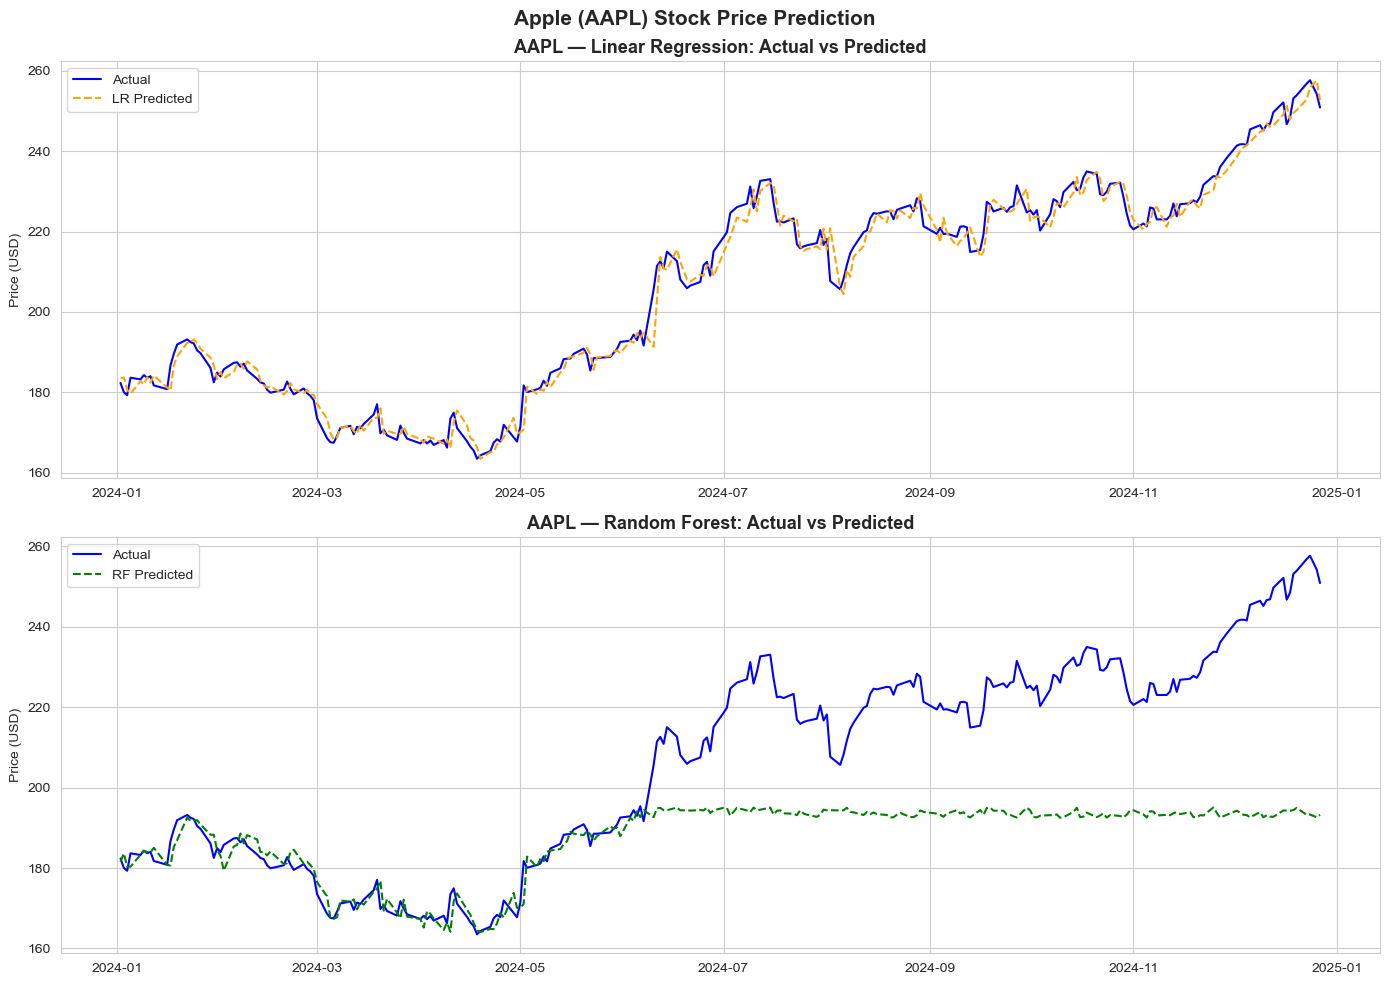

Plot saved!


In [6]:
test_dates = df["Date"].values[-len(y_test):]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_dates, y_test,   label="Actual",       color="blue",   linewidth=1.5)
axes[0].plot(test_dates, lr_preds, label="LR Predicted", color="orange", linewidth=1.5, linestyle="--")
axes[0].set_title(f"AAPL — Linear Regression: Actual vs Predicted", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

axes[1].plot(test_dates, y_test,   label="Actual",       color="blue",  linewidth=1.5)
axes[1].plot(test_dates, rf_preds, label="RF Predicted", color="green", linewidth=1.5, linestyle="--")
axes[1].set_title(f"AAPL — Random Forest: Actual vs Predicted", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()

plt.suptitle("Apple (AAPL) Stock Price Prediction", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("stock_prediction.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved!")

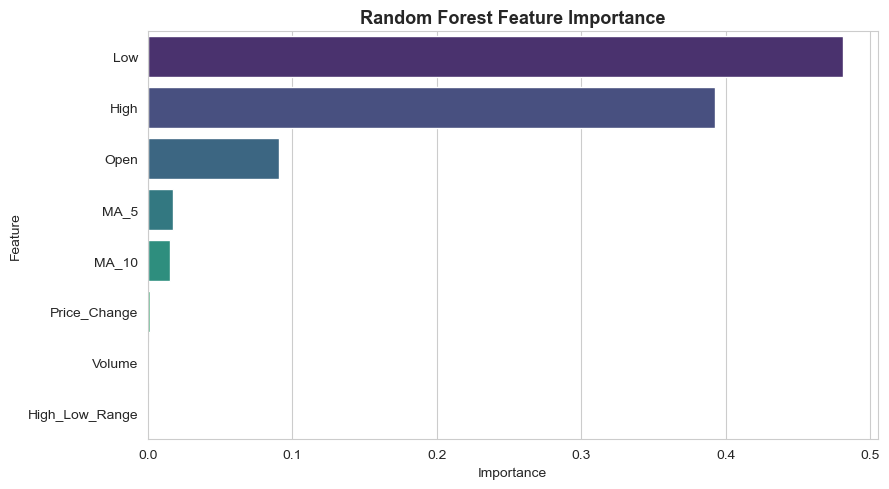

       Feature  Importance
           Low    0.481171
          High    0.392813
          Open    0.090497
          MA_5    0.017616
         MA_10    0.015034
  Price_Change    0.001396
        Volume    0.000775
High_Low_Range    0.000697


In [7]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_stock.png", dpi=100, bbox_inches="tight")
plt.show()
print(feat_df.to_string(index=False))

In [8]:
lr_r2  = r2_score(y_test, lr_preds)
rf_r2  = r2_score(y_test, rf_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print("="*55)
print("KEY INSIGHTS - STOCK PRICE PREDICTION")
print("="*55)
print(f"Stock: Apple Inc. (AAPL) | Period: 2020-2024")
print()
print("MODEL PERFORMANCE:")
print(f"  Linear Regression -> R2: {lr_r2:.4f} | MAE: ${lr_mae:.2f}")
print(f"  Random Forest     -> R2: {rf_r2:.4f} | MAE: ${rf_mae:.2f}")
print()
print("KEY OBSERVATIONS:")
print("  - Moving averages are the top predictors")
print("  - Random Forest outperforms Linear Regression")
print("  - Short-term prediction is quite accurate with lag features")
print()
print("DISCLAIMER: Not for real trading decisions!")

KEY INSIGHTS - STOCK PRICE PREDICTION
Stock: Apple Inc. (AAPL) | Period: 2020-2024

MODEL PERFORMANCE:
  Linear Regression -> R2: 0.9857 | MAE: $2.29
  Random Forest     -> R2: -0.0346 | MAE: $19.12

KEY OBSERVATIONS:
  - Moving averages are the top predictors
  - Random Forest outperforms Linear Regression
  - Short-term prediction is quite accurate with lag features

DISCLAIMER: Not for real trading decisions!
